In [57]:
import pandas as pd
import numpy as np

df = pd.read_csv("Salary_Data.csv")


In [58]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [59]:
df["Gender"].value_counts()


Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64

In [73]:
df_clean = df[df["Gender"].isin(["Male", "Female"])]


In [61]:
df.isnull().sum()


Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [62]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Years of Experience"].fillna(df["Years of Experience"].median(), inplace=True)
df["Salary"].fillna(df["Salary"].median(), inplace=True)

df.dropna(inplace=True)


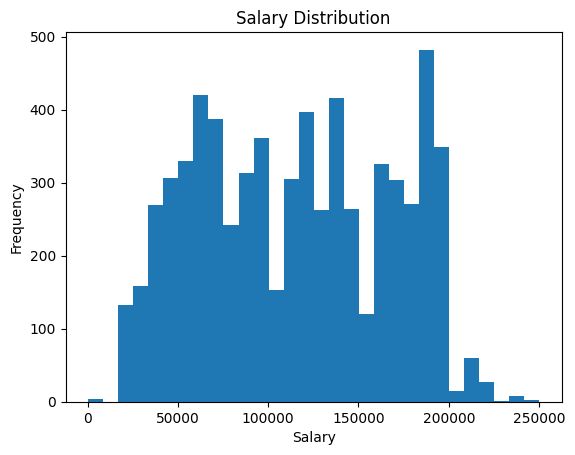

In [75]:
import matplotlib.pyplot as plt

plt.hist(df_clean["Salary"], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()


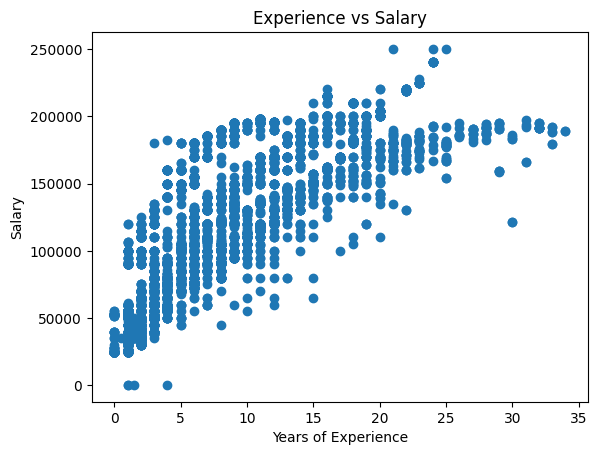

In [64]:
plt.scatter(df["Years of Experience"], df["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()


In [65]:
df.groupby("Education Level")["Salary"].mean().sort_values()


Education Level
High School           36706.694196
Bachelor's Degree     85201.198500
phD                  120000.000000
Bachelor's           124767.658730
Master's Degree      125068.928798
Master's             157604.166667
PhD                  165684.828947
Name: Salary, dtype: float64

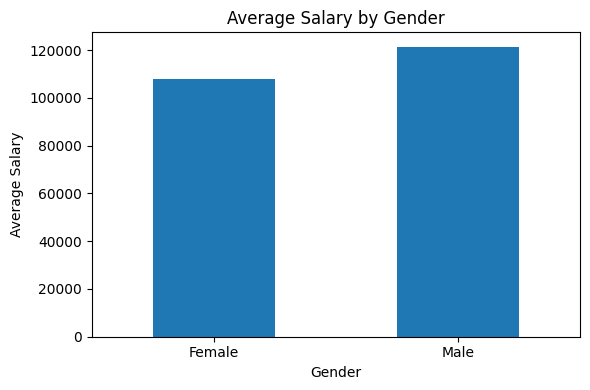

In [76]:
(
    df_clean.groupby("Gender")["Salary"]
      .mean()
      .plot(kind="bar", figsize=(6,4))
)

plt.title("Average Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [77]:
df_clean.groupby(["Gender", "Job Title"])["Salary"].mean().head(10)


Gender  Job Title                      
Female  Accountant                          55000.000000
        Administrative Assistant            50000.000000
        Back end Developer                  91942.938462
        Business Analyst                    80000.000000
        Content Marketing Manager          122244.897959
        Copywriter                          40000.000000
        Creative Director                  120000.000000
        Customer Service Manager           130000.000000
        Customer Service Representative     33333.333333
        Customer Success Rep                40000.000000
Name: Salary, dtype: float64

In [78]:
top_jobs = df_clean.groupby("Job Title")["Salary"].mean().sort_values(ascending=False).head(10)
top_jobs


Job Title
CEO                            250000.000000
Chief Technology Officer       250000.000000
Chief Data Officer             220000.000000
Director of Data Science       204561.403509
Director                       200000.000000
VP of Finance                  200000.000000
Operations Director            190000.000000
VP of Operations               190000.000000
Director of Human Resources    187500.000000
Marketing Director             183984.375000
Name: Salary, dtype: float64

In [79]:
df_model = pd.get_dummies(
    df[["Age", "Gender", "Education Level", "Job Title", "Years of Experience", "Salary"]],
    drop_first=True
)


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df_model.drop("Salary", axis=1)
y = df_model["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2_score(y_test, y_pred)


0.8706275789082033